In [1]:
# --- Sekcja 1: Konfiguracja i Importy ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import sys
import os

# Dodanie ścieżki do konfiguracji projektu
sys.path.append('../src')
import config

# Ustawienia estetyczne wykresów
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

In [4]:
# --- Sekcja 2: Funkcja Automatycznego Raportu EDA ---
def perform_medical_eda(dataset_name):
    print(f"{'='*30}\nANALIZA: {dataset_name.upper()}\n{'='*30}")
    
    # Wczytanie danych
    file_path = config.PROCESSED_DATA_DIR / f"{dataset_name}_processed.csv"
    if not file_path.exists():
        print(f"Błąd: Plik {file_path} nie istnieje. Uruchom najpierw preprocessor.py.")
        return
    
    df = pd.read_csv(file_path)
    
    # Pobranie metadanych ze słownika (z config.py)
    if dataset_name in config.UCI_DATASETS:
        target_col = config.UCI_DATASETS[dataset_name]['target_col']
    else:
        target_col = config.OPENML_DATASETS[dataset_name]['target_col']

    # 1. Analiza brakujących danych (Missingness Map)
    # Kluczowe dla zbioru Chronic Kidney Disease (CKD)
    plt.figure(figsize=(10, 4))
    msno.matrix(df)
    plt.title(f"Mapa brakujących danych: {dataset_name}")
    plt.show()

    # 2. Rozkład klasy docelowej (Class Imbalance)
    # Krytyczne dla zbioru Cervical Cancer
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette='viridis')
    plt.title(f"Rozkład klas (Target: {target_col})")
    plt.show()
    
    imbalance_ratio = df[target_col].value_counts(normalize=True).min()
    print(f"Najmniejsza klasa stanowi: {imbalance_ratio:.2%} zbioru.")

    # 3. Macierz Korelacji (Redundancja Cech)
    # Ważne dla Parkinson's (wiele cech akustycznych może być silnie skorelowanych)
    plt.figure(figsize=(12, 10))
    corr = df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='RdBu', center=0, annot=False, linewidths=.5)
    plt.title(f"Korelacje cech klinicznych: {dataset_name}")
    plt.show()

    # 4. Statystyki opisowe
    print("\nStatystyki kluczowych cech:")
    display(df.describe().T.head(10)) # Pokazujemy pierwsze 10 cech dla czytelności

ANALIZA: BREAST_CANCER


<Figure size 1000x400 with 0 Axes>

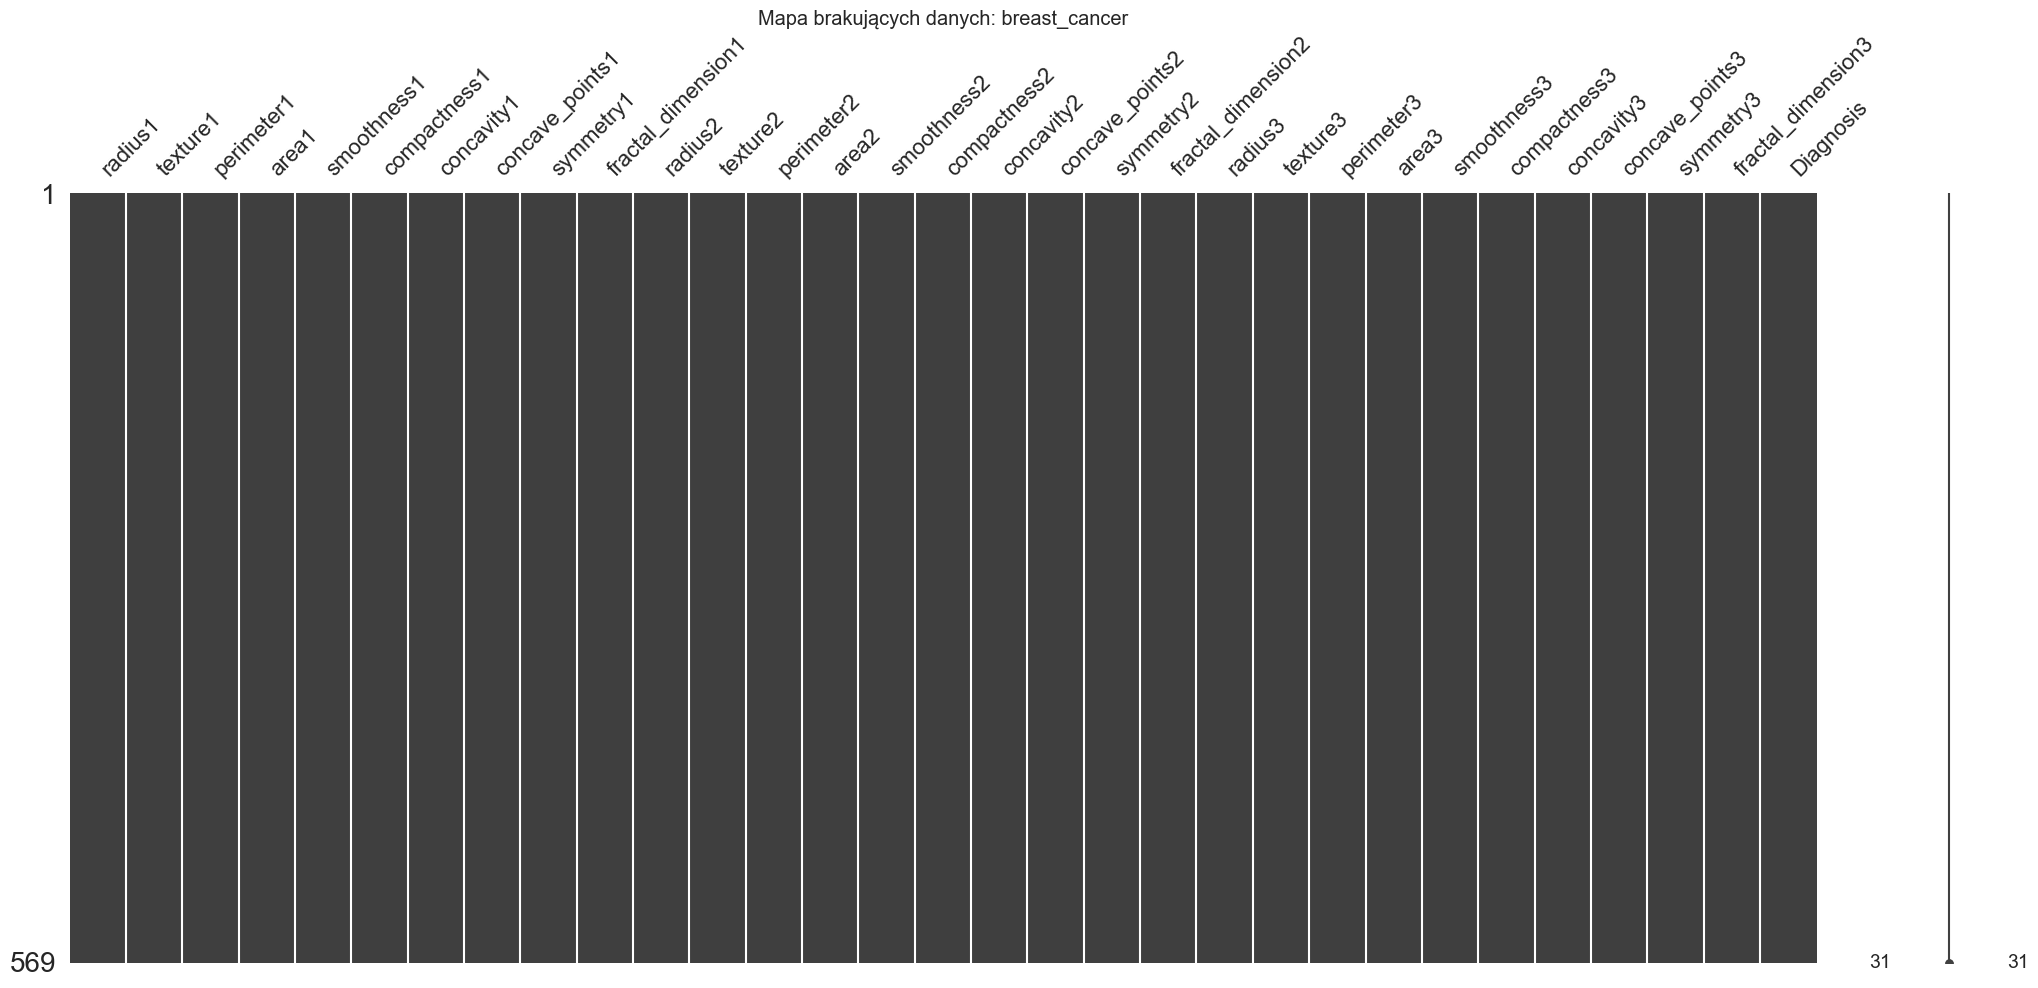

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


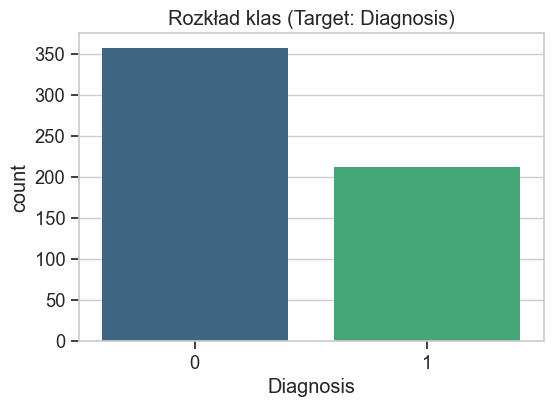

Najmniejsza klasa stanowi: 37.26% zbioru.


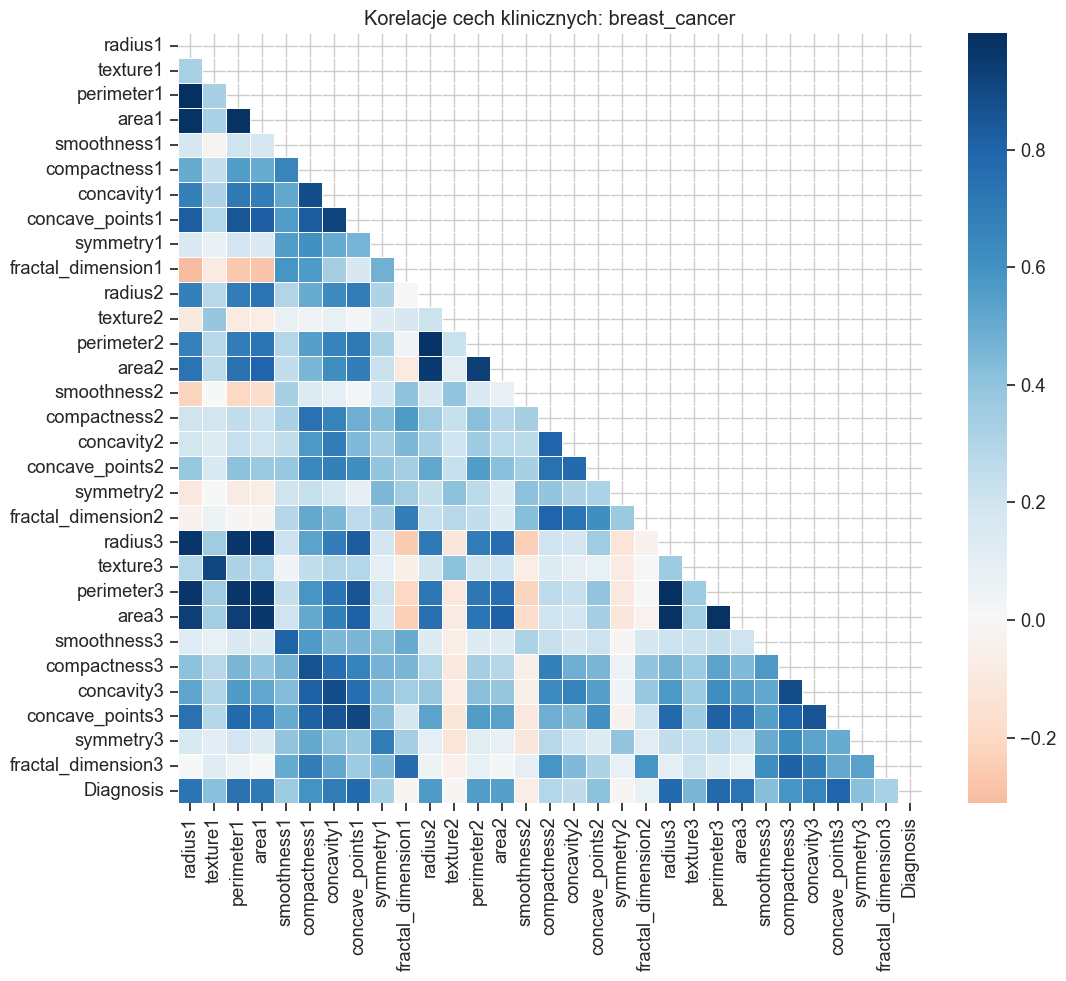


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
texture1,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
perimeter1,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
area1,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
compactness1,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
concavity1,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
concave_points1,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
symmetry1,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


ANALIZA: HEART_DISEASE


<Figure size 1000x400 with 0 Axes>

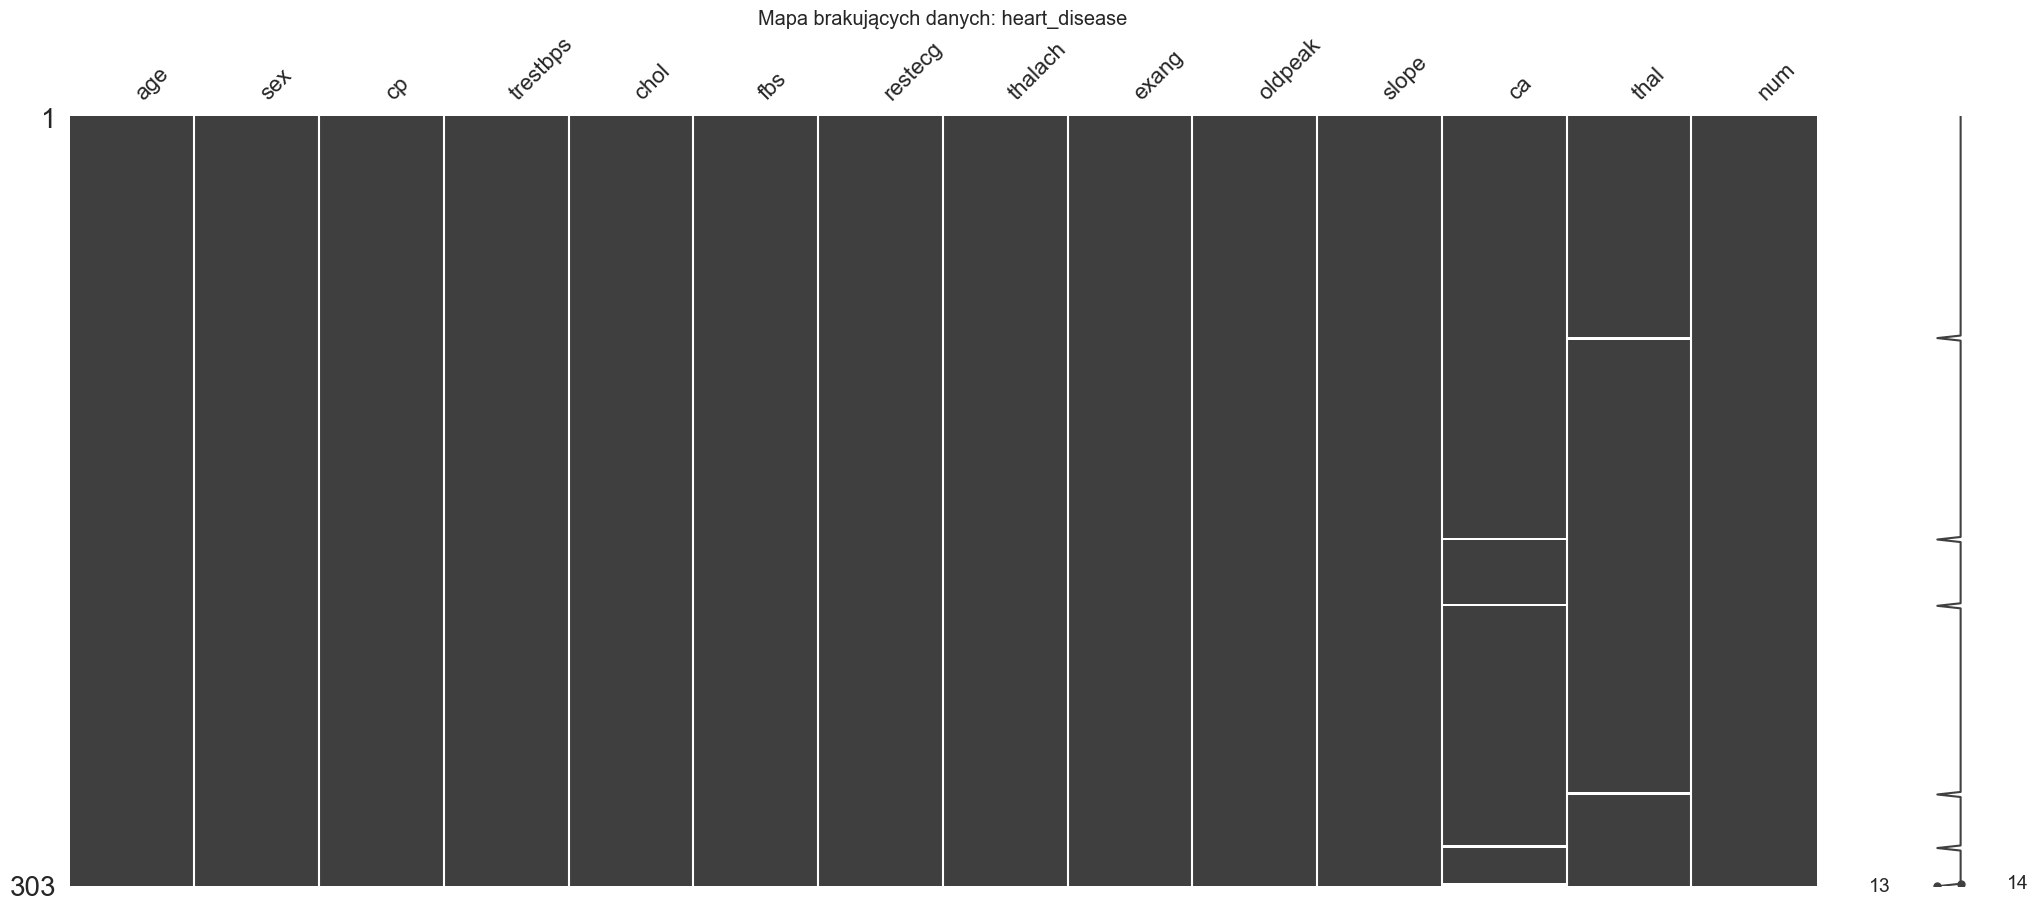

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


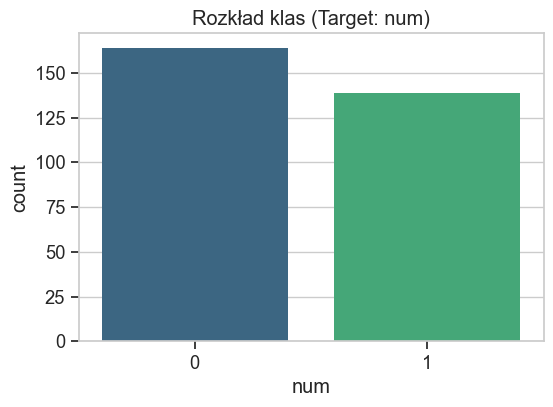

Najmniejsza klasa stanowi: 45.87% zbioru.


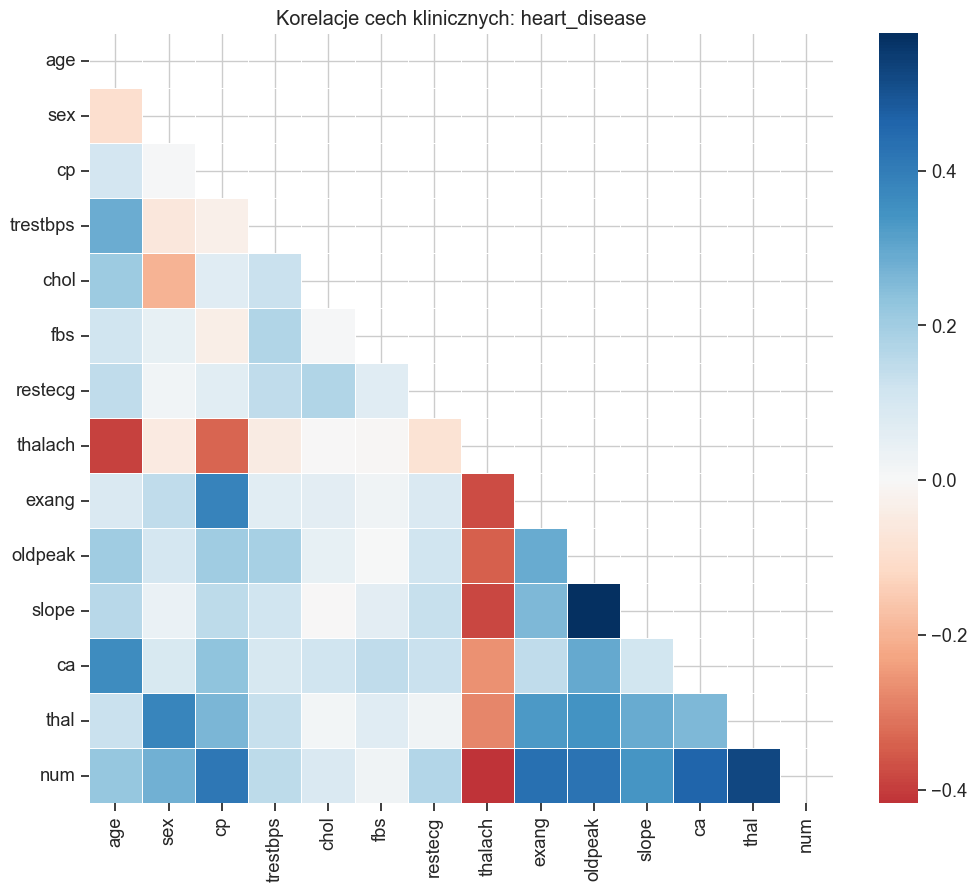


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


ANALIZA: CHRONIC_KIDNEY_DISEASE


<Figure size 1000x400 with 0 Axes>

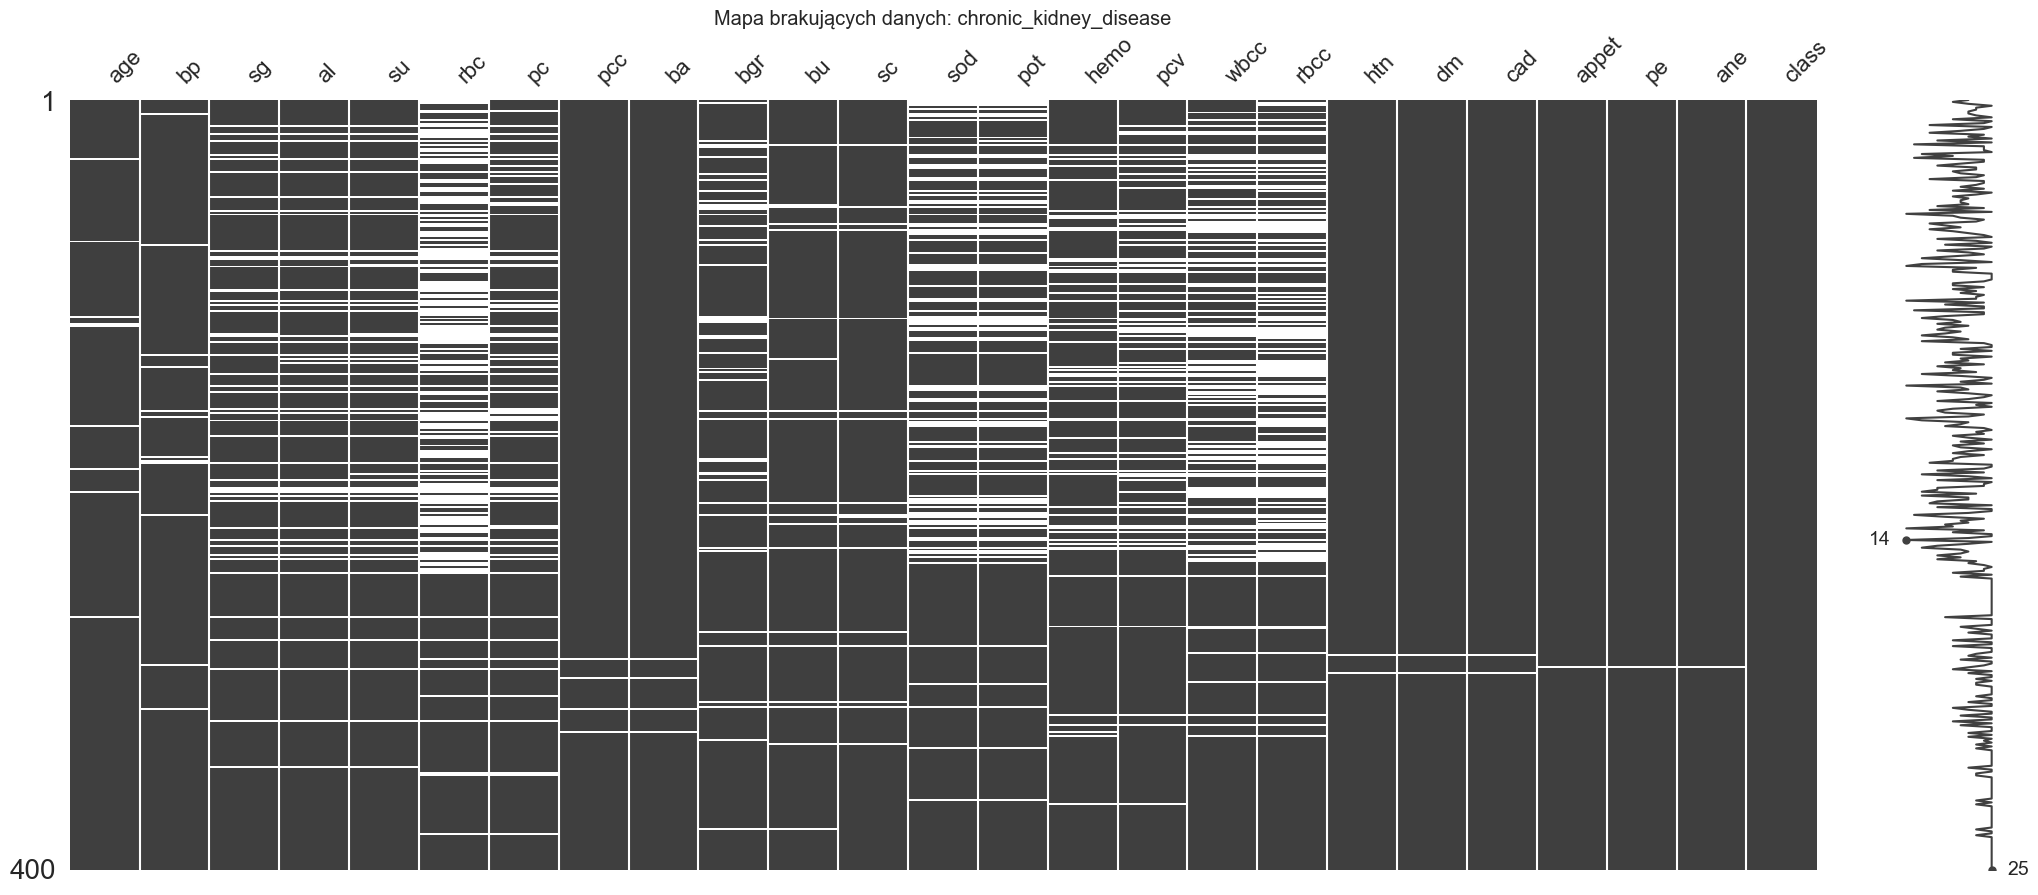

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


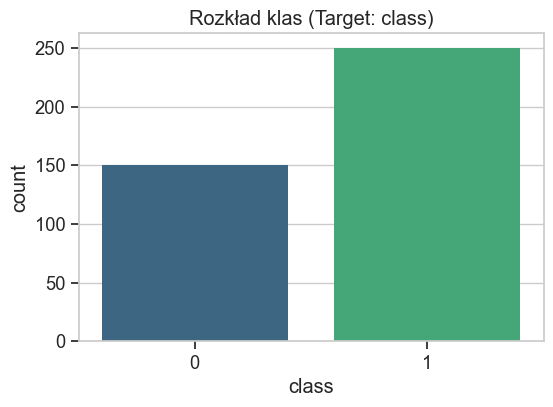

Najmniejsza klasa stanowi: 37.50% zbioru.


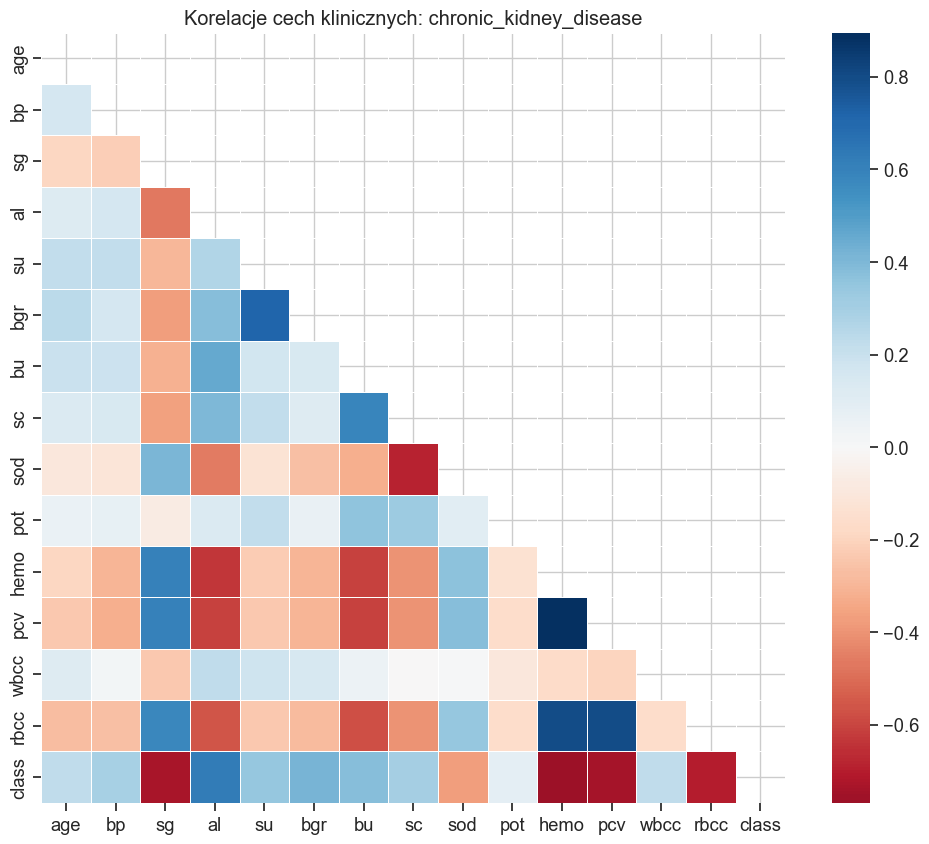


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


ANALIZA: PARKINSONS


<Figure size 1000x400 with 0 Axes>

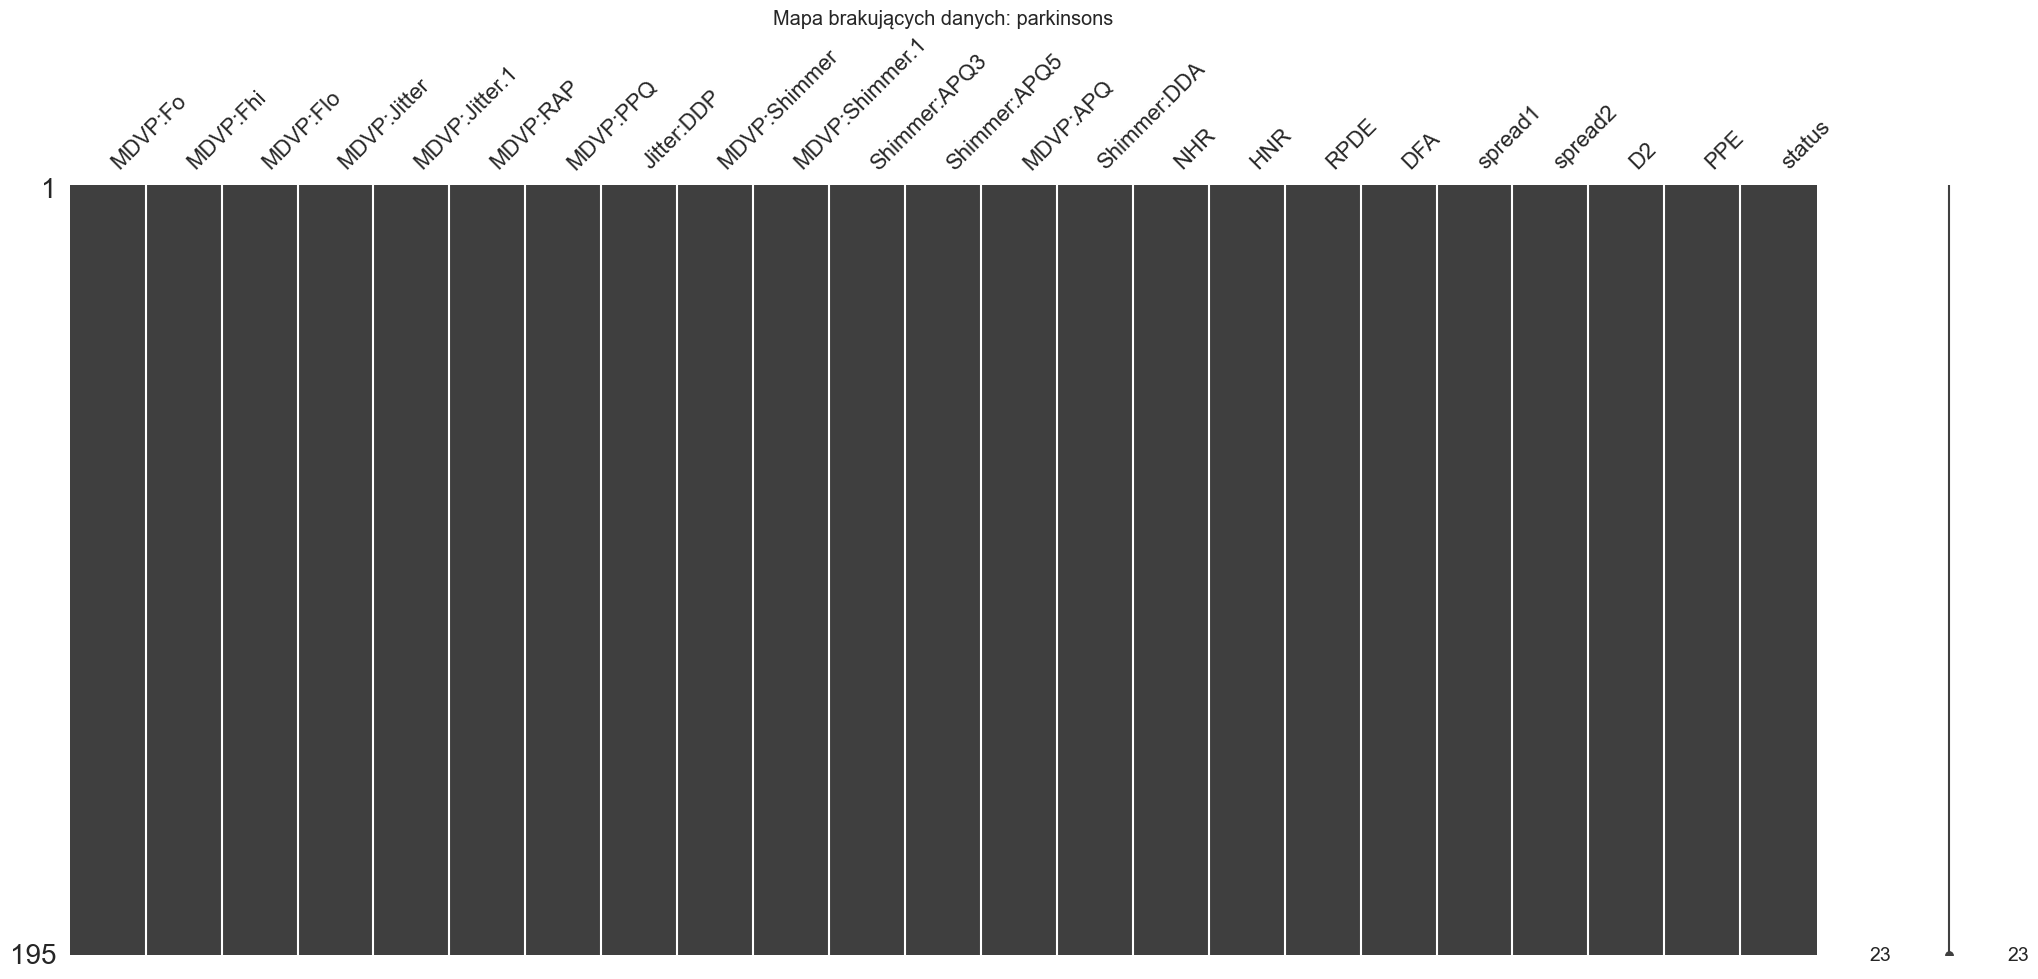

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


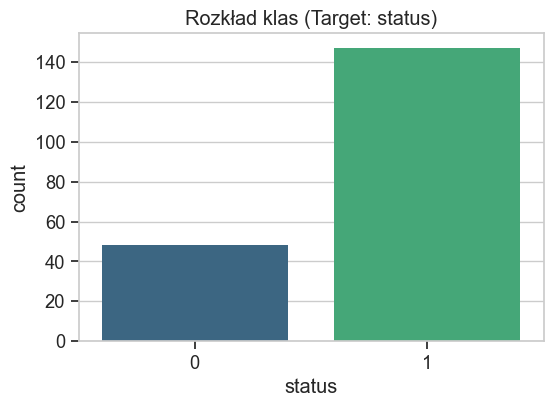

Najmniejsza klasa stanowi: 24.62% zbioru.


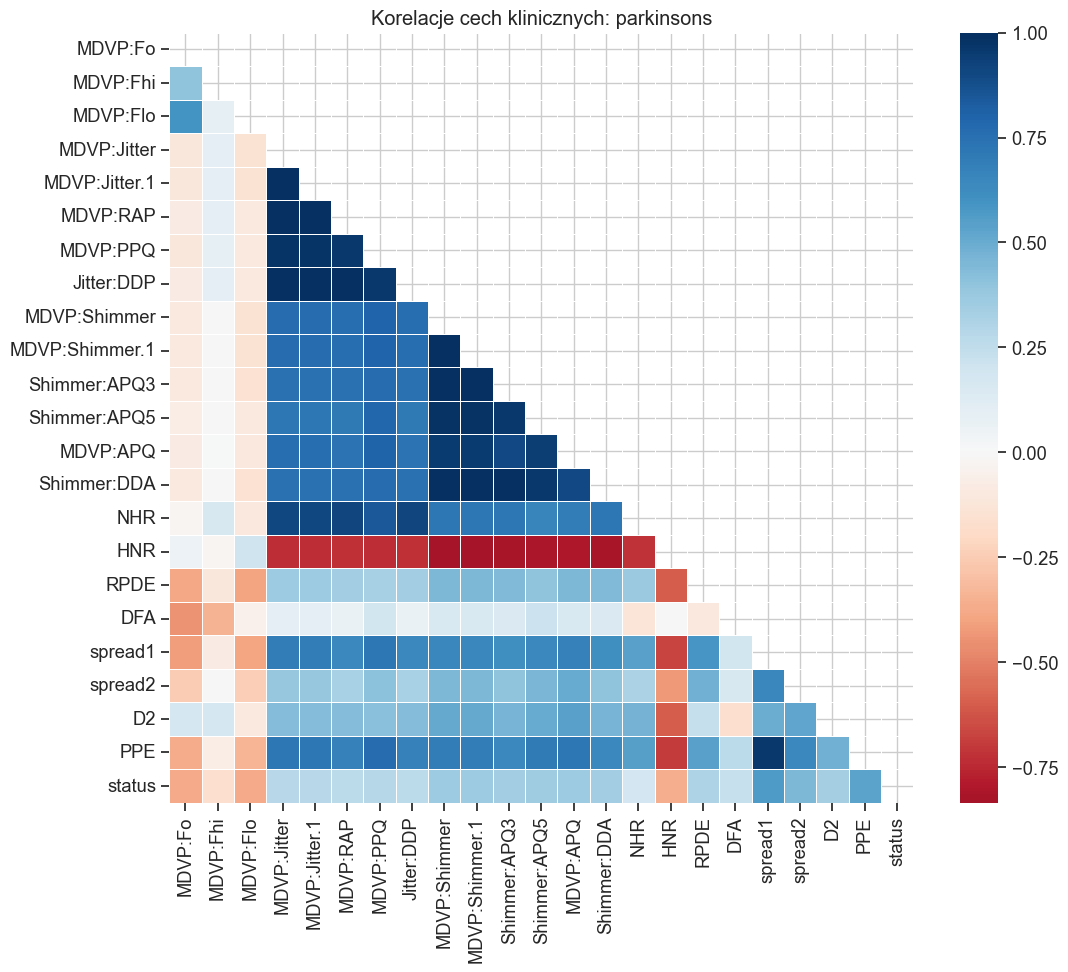


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
MDVP:Fo,195.0,154.228641,41.390065,88.33300,117.572000,148.79000,182.769000,260.10500
MDVP:Fhi,195.0,197.104918,91.491548,102.14500,134.862500,175.82900,224.205500,592.03000
MDVP:Flo,195.0,116.324631,43.521413,65.47600,84.291000,104.31500,140.018500,239.17000
MDVP:Jitter,195.0,0.006220,0.004848,0.00168,0.003460,0.00494,0.007365,0.03316
MDVP:Jitter.1,195.0,0.006220,0.004848,0.00168,0.003460,0.00494,0.007365,0.03316
MDVP:RAP,195.0,0.003306,0.002968,0.00068,0.001660,0.00250,0.003835,0.02144
MDVP:PPQ,195.0,0.003446,0.002759,0.00092,0.001860,0.00269,0.003955,0.01958
Jitter:DDP,195.0,0.009920,0.008903,0.00204,0.004985,0.00749,0.011505,0.06433
MDVP:Shimmer,195.0,0.029709,0.018857,0.00954,0.016505,0.02297,0.037885,0.11908
MDVP:Shimmer.1,195.0,0.029709,0.018857,0.00954,0.016505,0.02297,0.037885,0.11908


ANALIZA: CERVICAL_CANCER


<Figure size 1000x400 with 0 Axes>

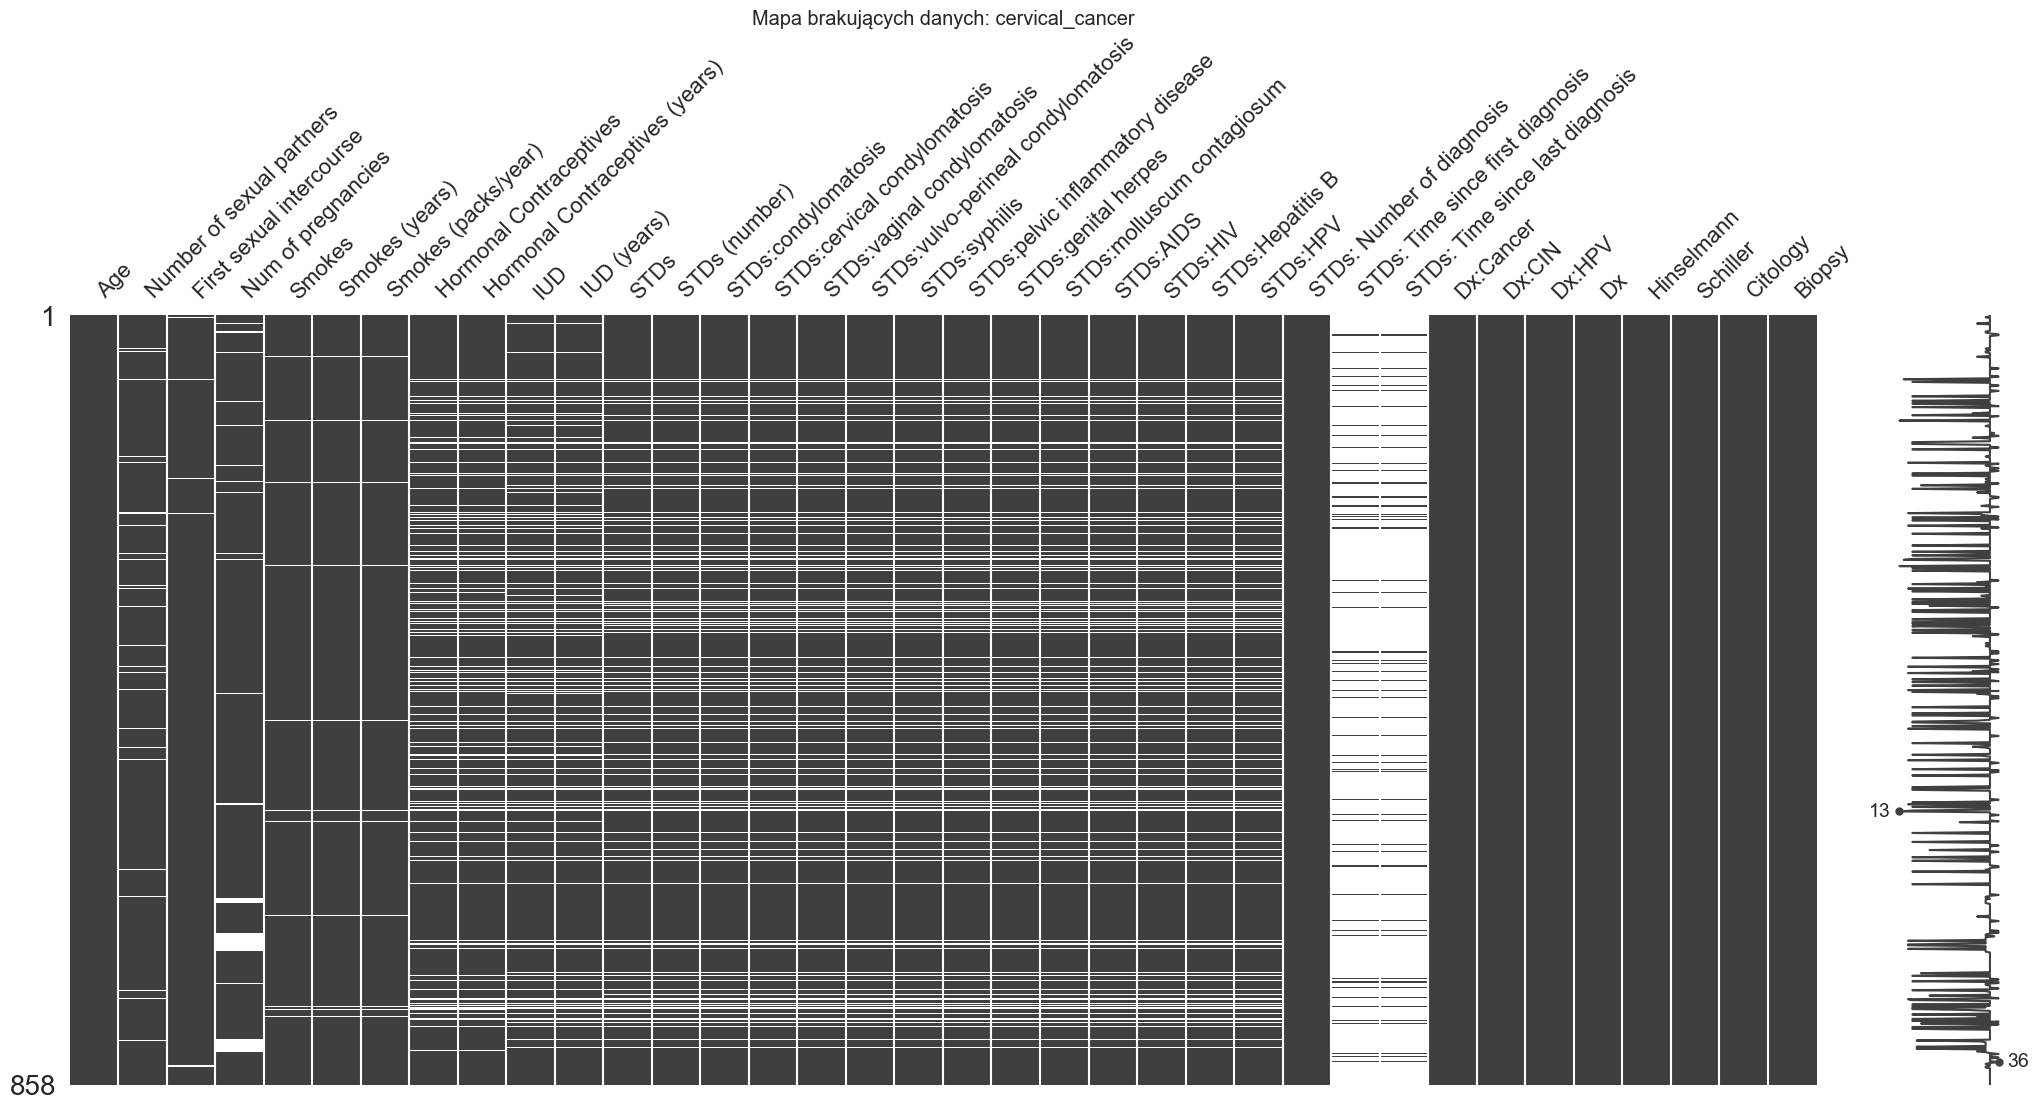

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


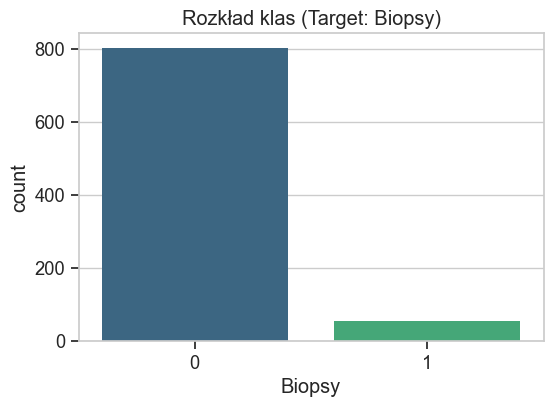

Najmniejsza klasa stanowi: 6.41% zbioru.


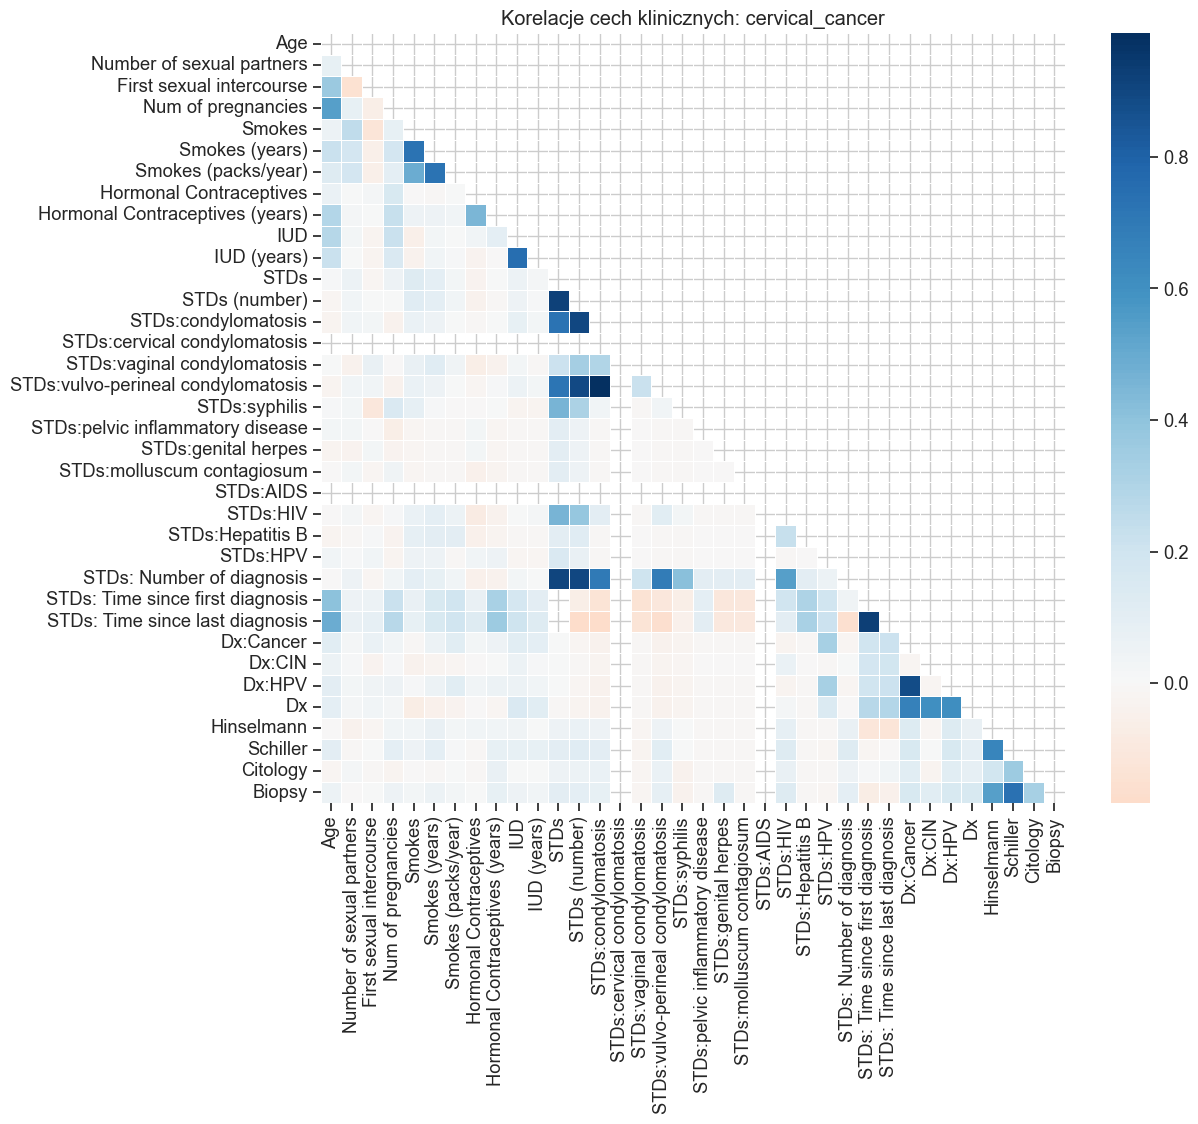


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.527644,1.667760,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995300,2.803355,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.275561,1.447414,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.145562,0.352876,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.219721,4.089017,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453144,2.226610,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641333,0.479929,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256419,3.764254,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112011,0.315593,0.0,0.0,0.0,0.0,1.0


ANALIZA: CARDIOTOCOGRAPHY


<Figure size 1000x400 with 0 Axes>

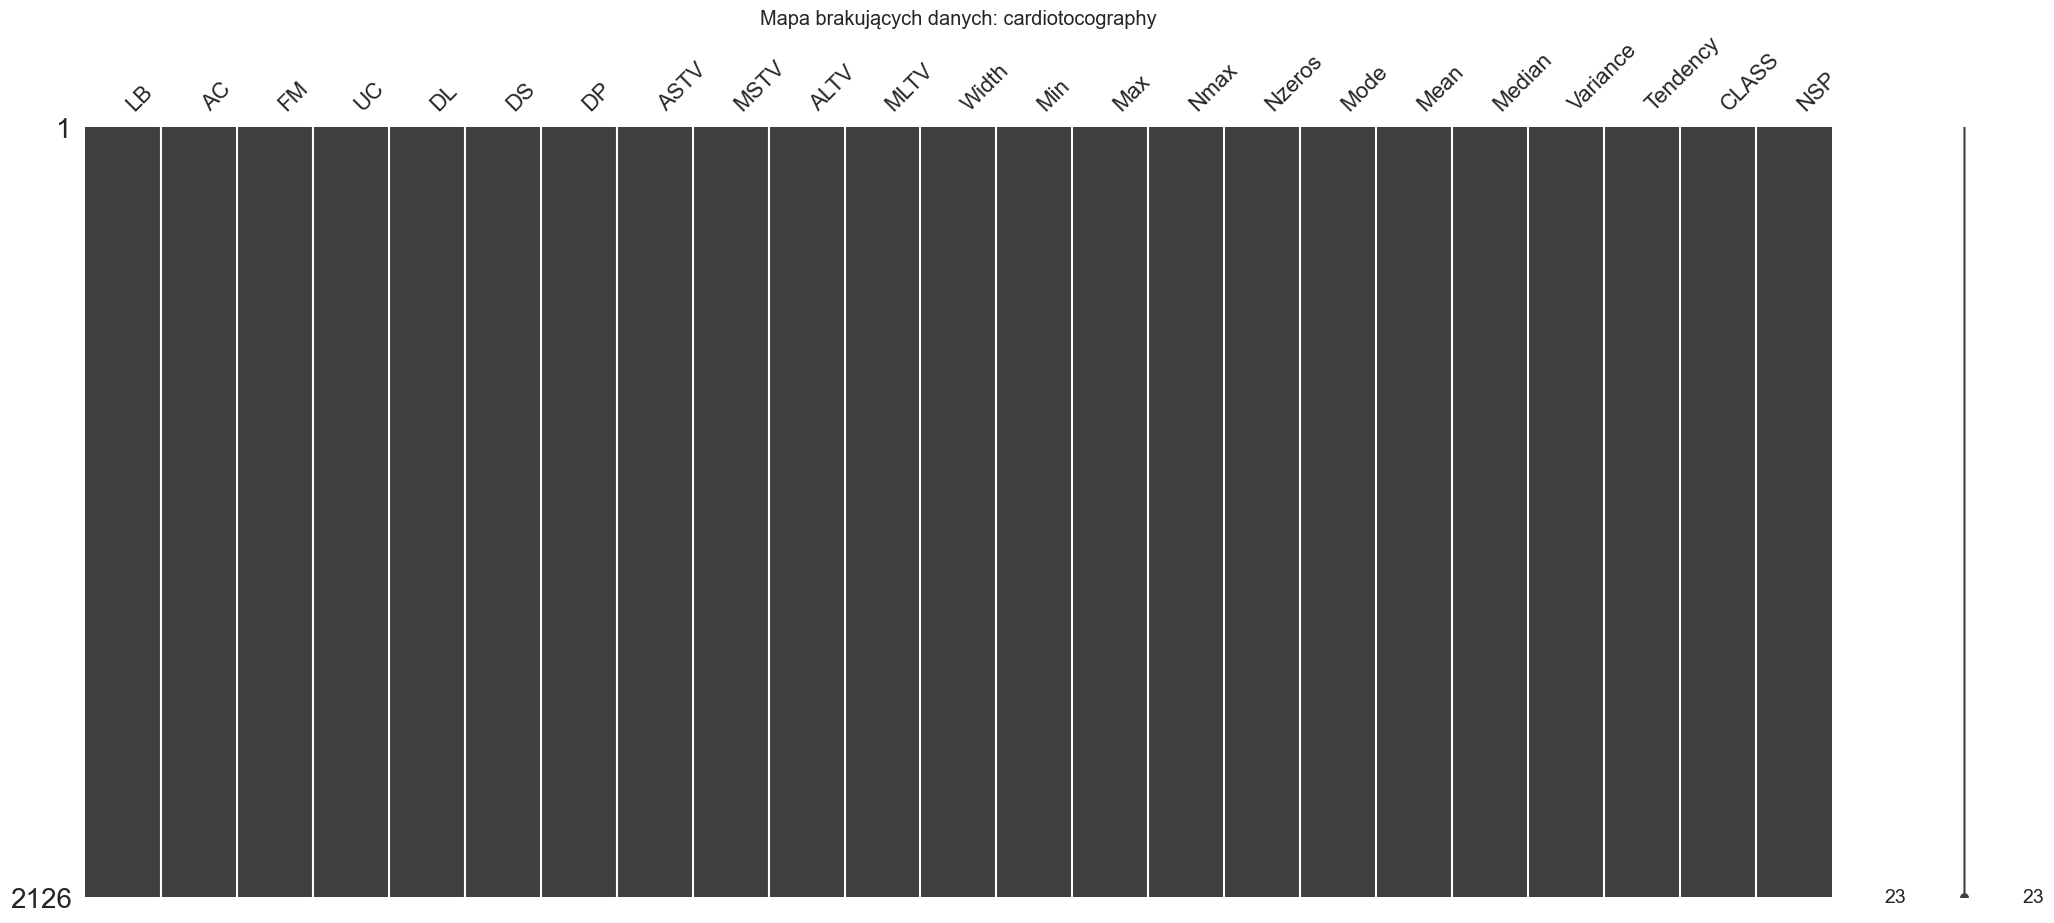

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


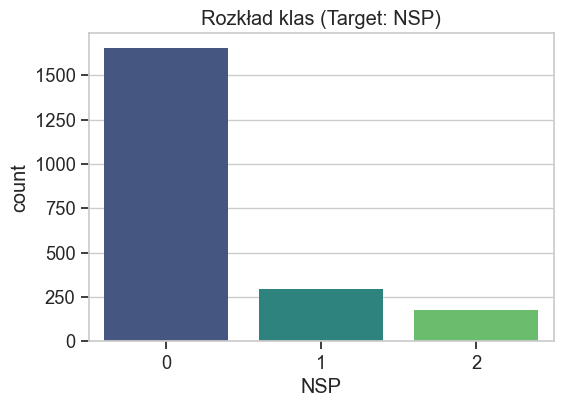

Najmniejsza klasa stanowi: 8.28% zbioru.


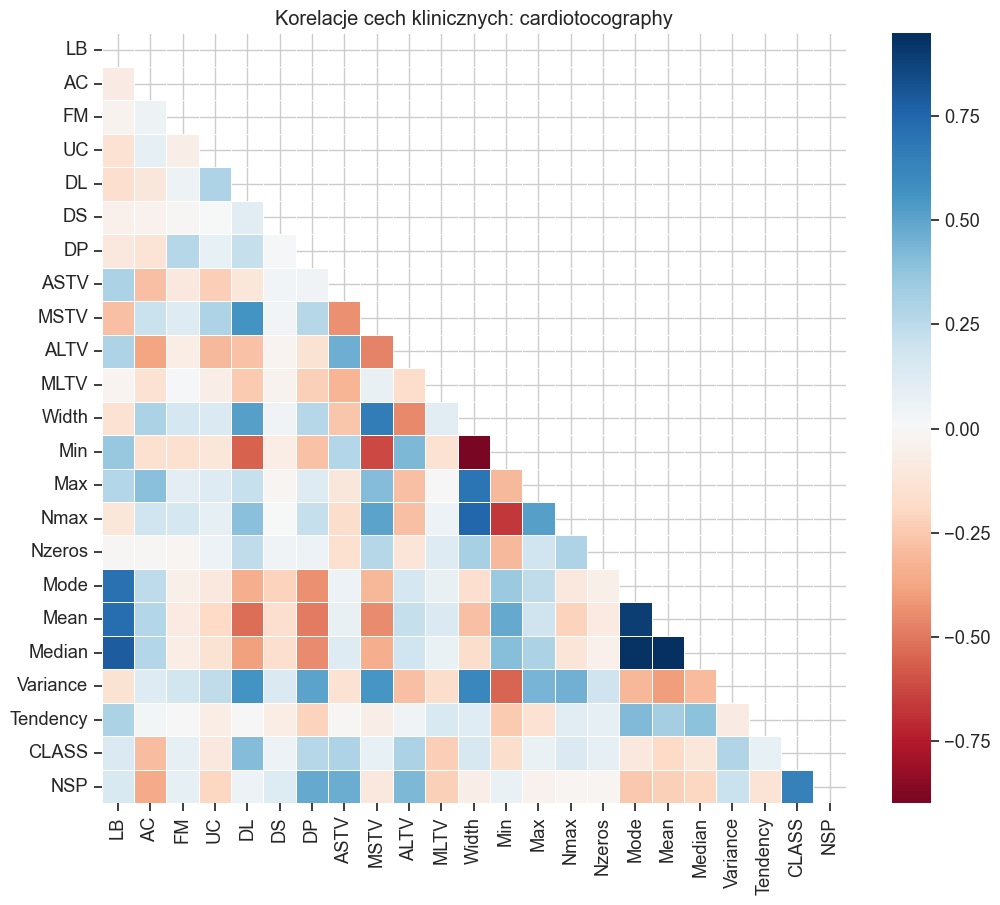


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
LB,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
AC,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
FM,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
UC,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
DL,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
DS,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
DP,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
ASTV,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
MSTV,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
ALTV,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


ANALIZA: PIMA_DIABETES


<Figure size 1000x400 with 0 Axes>

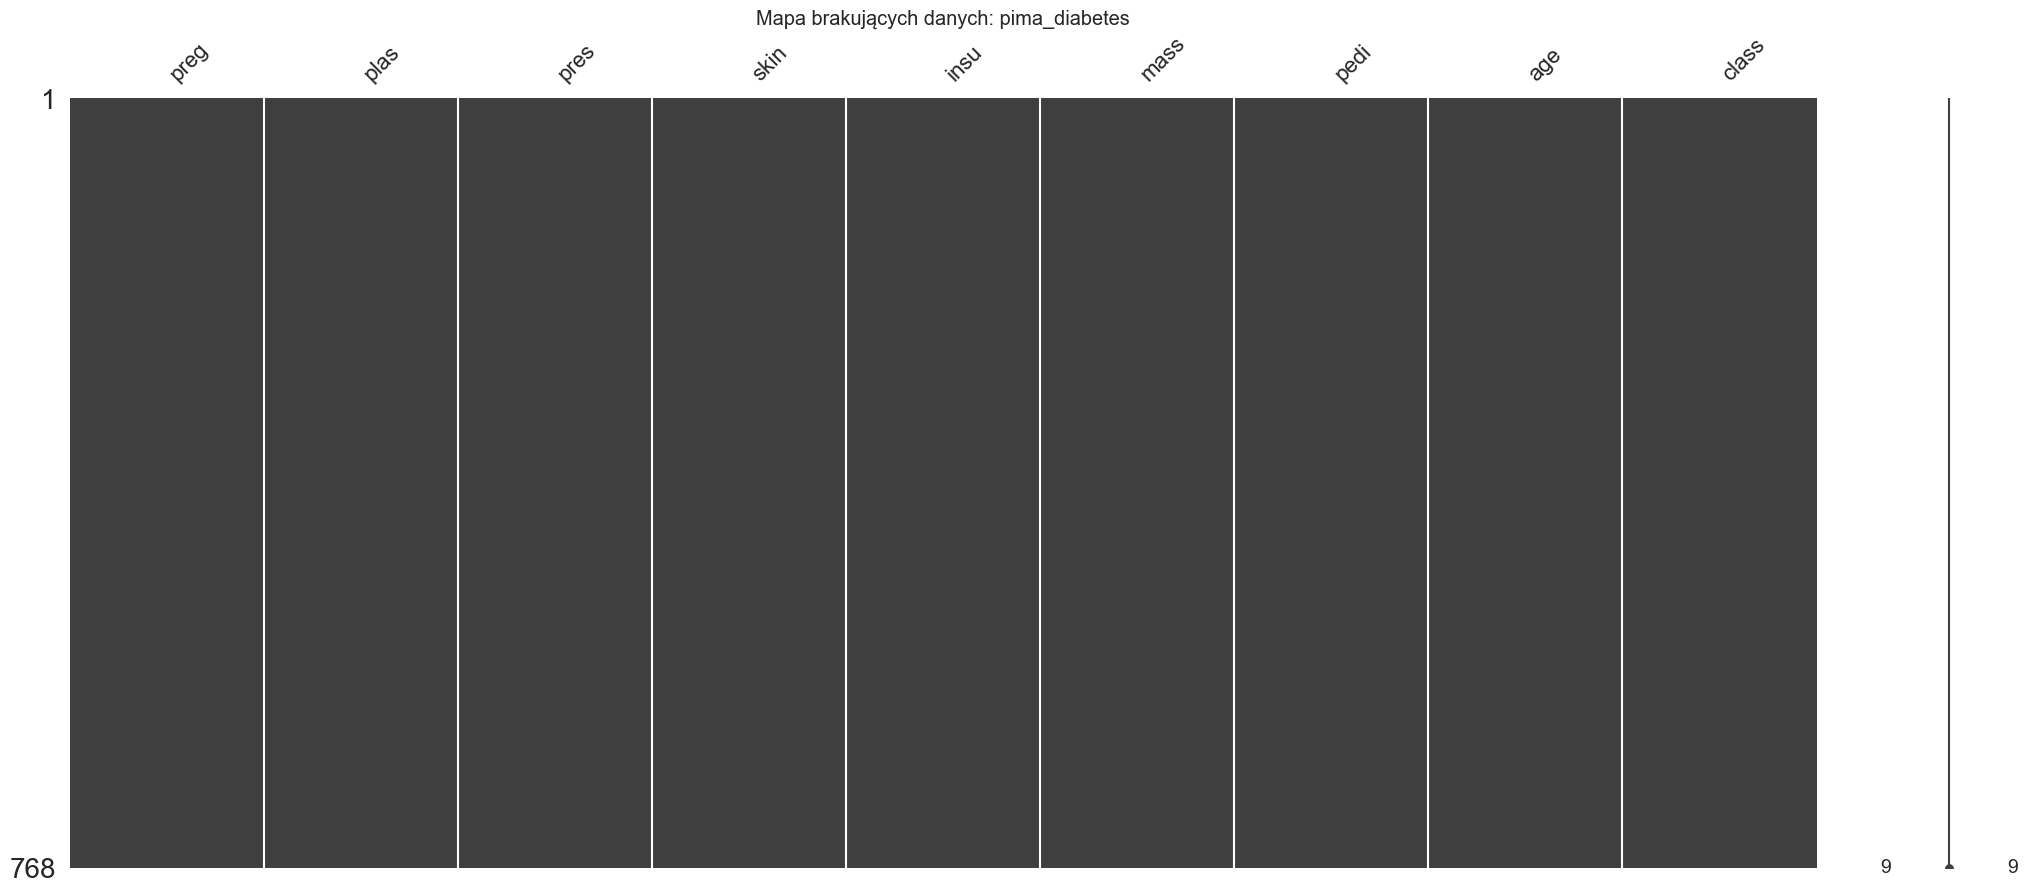

C:\Users\rwodz\AppData\Local\Temp\ipykernel_8968\3989155864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


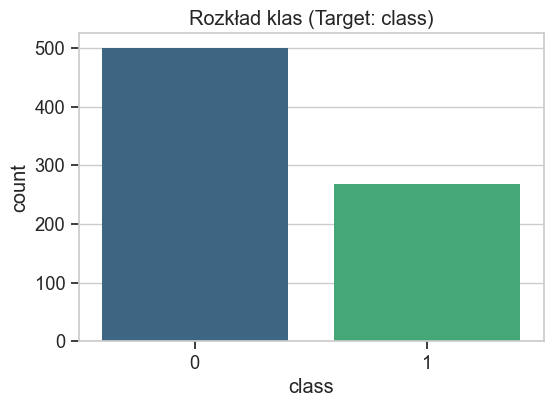

Najmniejsza klasa stanowi: 34.90% zbioru.


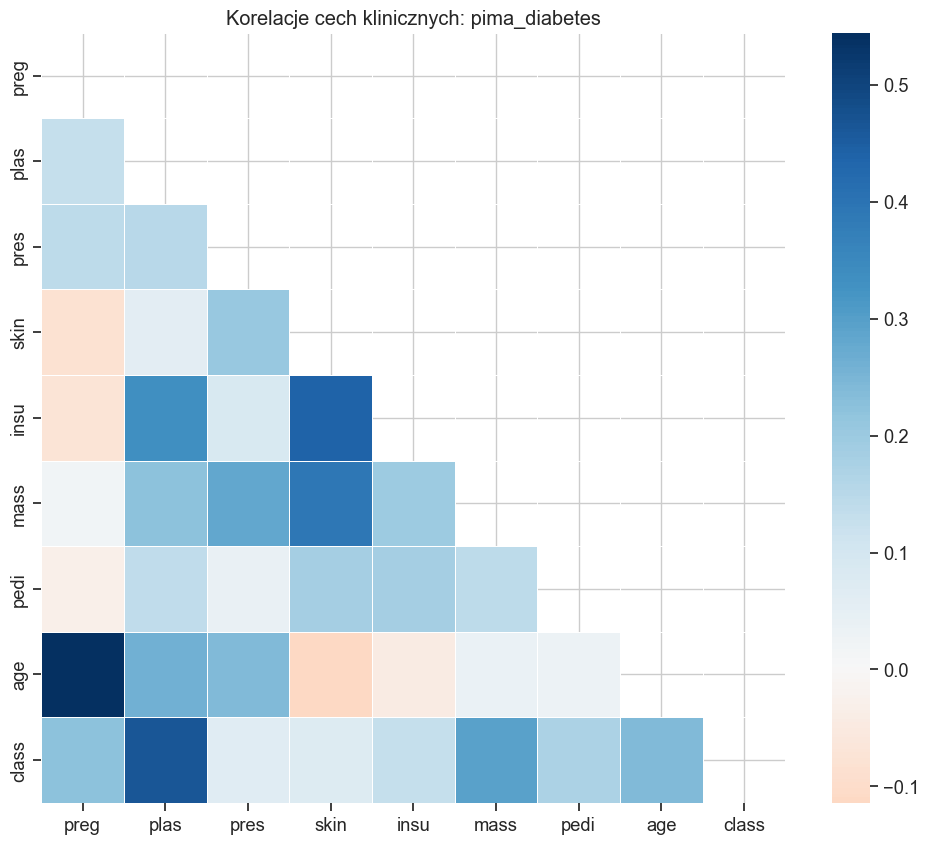


Statystyki kluczowych cech:


,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insu,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
# --- Sekcja 3: Uruchomienie dla wszystkich zbiorów ---
datasets_to_analyze = list(config.UCI_DATASETS.keys()) + list(config.OPENML_DATASETS.keys())

for ds in datasets_to_analyze:
    perform_medical_eda(ds)